In [1]:
!pip install codecarbon

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import pandas as pd
import pickle
from trust_library.core import TrustEvaluator
from trust_library.factsheet import (
    load_factsheet_default,
    load_factsheet,
    save_factsheet, 
    create_factsheet_interactive,
    create_factsheet,
)

import matplotlib.pyplot as plt
import seaborn as sns
import json

from trust_library.utils import to_json_safe
import plotly.express as px

if __name__ == "__main__":

    factsheet = load_factsheet_default() #load_factsheet("factsheet.json")

    with open("model.pkl", "rb") as f:
        loaded_model = pickle.load(f)

    train_loaded = pd.read_csv("train.csv")
    test_loaded = pd.read_csv("test.csv")

    evaluator = TrustEvaluator(
        model=loaded_model,
        train_data=train_loaded,
        test_data=test_loaded,
        factsheet=factsheet,
        config_path="trust_library/configs.json"
    )

    results = evaluator.compute()

    print("\n=== RESULTADOS FINAL ===")
    print(f"Global Trust Score: {results['trust_score']}")
    print(f"Pillar Scores:\n{json.dumps(results['pillar_score'], indent=4)}")
    print("\nDetalles (Scores brutos):\n" + json.dumps(results['details'], indent=4))

    print("\nPropiedades calculadas:\n" + json.dumps(to_json_safe(results['properties']), indent=4))

[codecarbon WARNING @ 12:33:50] Multiple instances of codecarbon are allowed to run at the same time.



=== RESULTADOS FINAL ===
Global Trust Score: 2.6
Pillar Scores:
{
    "fairness": 2.9,
    "accountability": 1.6,
    "privacy": 5.0,
    "sustainability": 1.0
}

Detalles (Scores brutos):
{
    "fairness": {
        "underfitting": 5,
        "overfitting": 2,
        "class_balance": 1,
        "statistical_parity_difference": 1,
        "disparate_impact": 5,
        "equal_opportunity_difference": 3,
        "average_odds_difference": 4,
        "accuracy_parity": 5,
        "predictive_parity": 3,
        "treatment_equality": 2,
        "calibration": 1,
        "well_calibration": 1,
        "generalized_entropy": 1,
        "theil_index": 1,
        "coefficient_variation": 2,
        "consistency": 5,
        "class_imbalance": 5,
        "kl_divergence": 1,
        "smoothed_edf": 1,
        "bias_amplification": 5,
        "cohens_d": 1
    },
    "accountability": {
        "train_test_split": 5.0,
        "missing_data": 1,
        "normalization": 1,
        "regularizat

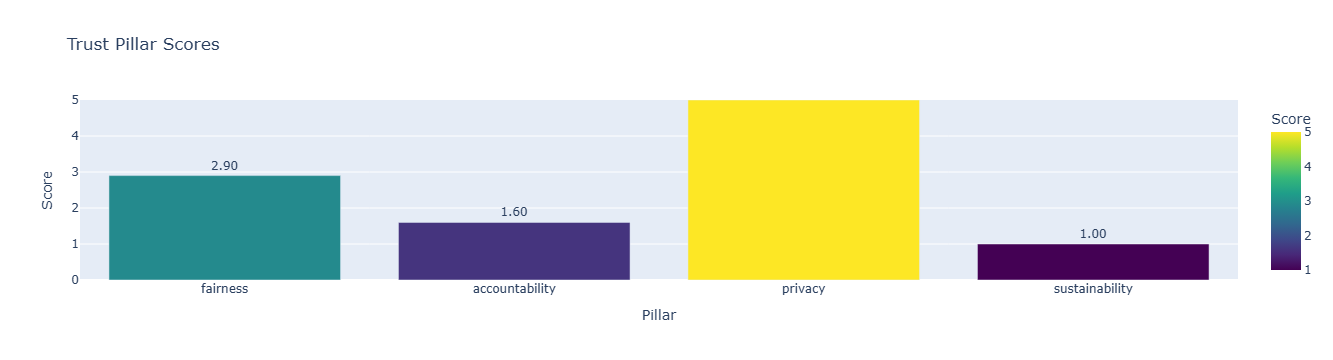

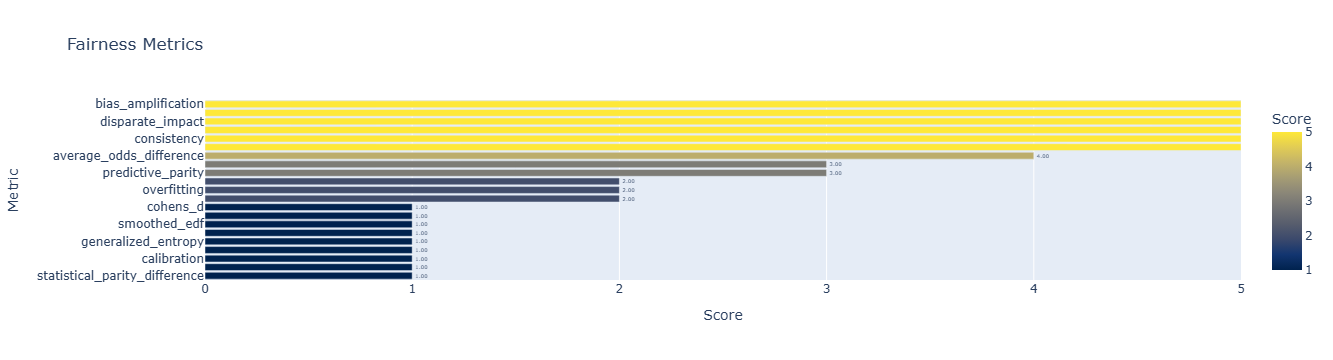

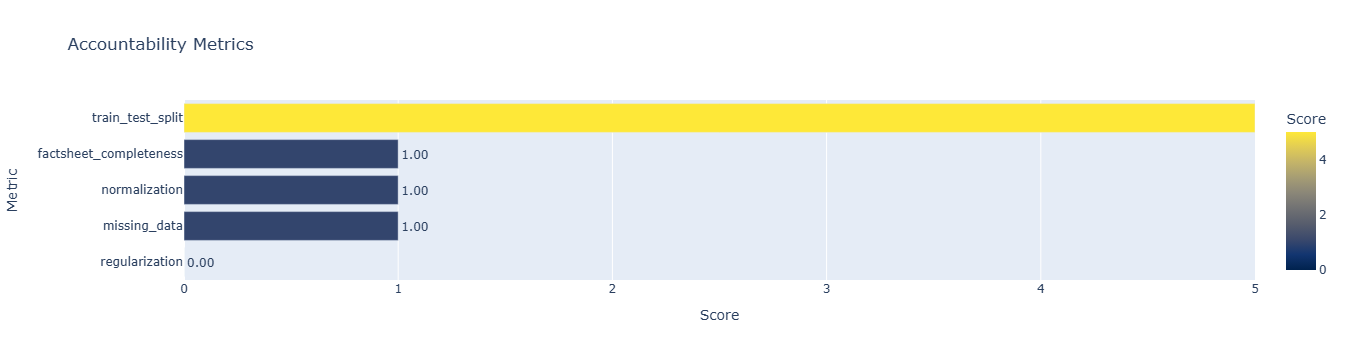

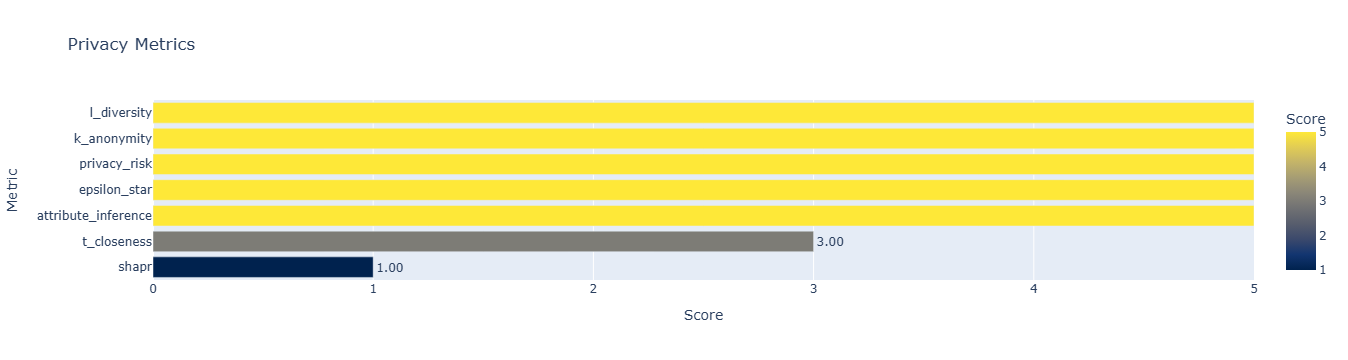

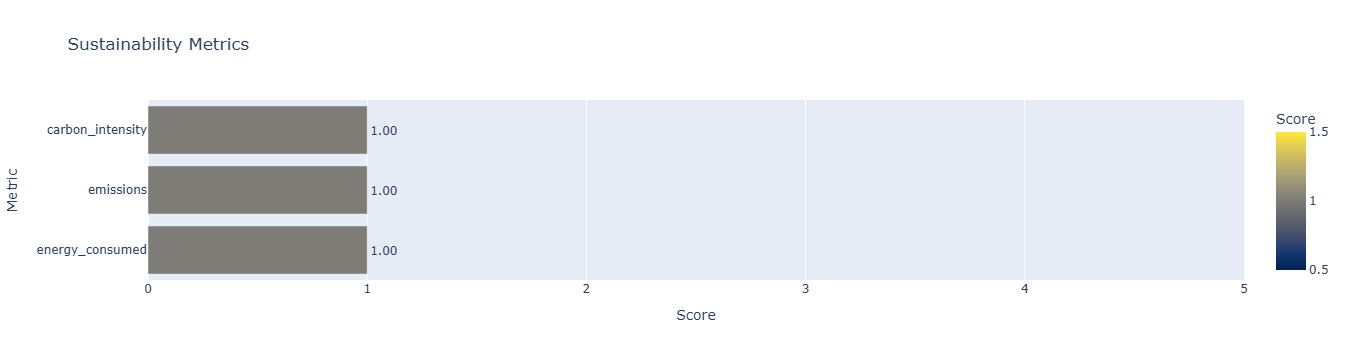

In [3]:
# === Cargar datos ===

pillar_scores = results["pillar_score"]
details = results["details"]

# === Gráfico de barras de pilares ===
df_pillars = pd.DataFrame(list(pillar_scores.items()), columns=["Pillar", "Score"])
fig_pillars = px.bar(
    df_pillars,
    x="Pillar",
    y="Score",
    text="Score",
    color="Score",
    color_continuous_scale="Viridis",
    range_y=[0, 5],
    title="Trust Pillar Scores"
)
fig_pillars.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig_pillars.show()  # Esto abre un navegador con el gráfico interactivo

# === Gráficos por métricas individuales de cada pilar ===
for pillar, metrics in details.items():
    df_metrics = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])
    df_metrics = df_metrics.sort_values("Score")  # Para que las barras horizontales estén ordenadas
    fig = px.bar(
        df_metrics,
        x="Score",
        y="Metric",
        orientation="h",
        text="Score",
        color="Score",
        color_continuous_scale="Cividis",
        range_x=[0, 5],
        title=f"{pillar.capitalize()} Metrics"
    )
    fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
    fig.show()  # Abre cada gráfico en una ventana o pestaña del navegador